# Absorption Coefficient Analytical Calculation in The Ideal Case

In [1]:
#  imports
from IPython.display import Markdown, display
import numpy as np
import matplotlib.pyplot as plt

## Constants

In [3]:
# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters ---
f_S12_to_P12 = 377.107463380e12        # Hz
f_S12F1_to_S12 = 4.271676631815181e9  # Hz
f_P12F1_to_P12 = 509.06e6           # Hz
f_p12F1_to_P12F2 = 814.5e6          # Hz

# Central transition frequency: S1/2 F=1 → P1/2 F'=1
f_D11 = f_S12_to_P12 + f_S12F1_to_S12 - f_P12F1_to_P12
f_D12 = f_D11 + f_p12F1_to_P12F2

# Wavelength
lambda_D11 = c / f_D11
lambda_D12 = c / f_D12

# Linewidth (Γ_D1)
Gamma_D1 = 36.129e6  # Hz

# Peak cross-section (sigma_0)
sigma_D11_0 = 3 * lambda_D11**2 / (2 * np.pi)
sigma_D12_0 = 3 * lambda_D12**2 / (2 * np.pi)

# Rubidium-87 mass
m_Rb87 = 86.909180527 * amu

# Temperature and Doppler parameter
T = 300.0  # K
u = np.sqrt(2 * k_B * T / m_Rb87)

# Rb vapor number density (low-pressure) (assumed)
N = 1e10 * 1e6  # 1e10 cm^-3 = 1e16 m^-3

# Saturation and pump intensities
I_sat_D11 = h * f_D11 * Gamma_D1 / (2 * sigma_D11_0)
I_sat_D12 = h * f_D12 * Gamma_D1 / (2 * sigma_D12_0)
I_pu = I_sat_D11  # set equal I_sat_D11


## Algorithm

In [4]:
def f_D(v, u):
    """Maxwell–Boltzmann velocity distribution (normalized)."""
    return (1 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))

def L(delta, Gamma):
    """Lorentzian lineshape (dimensionless)."""
    return ((Gamma**2) / 4) / (delta**2 + (Gamma**2) / 4)

def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        shifted = L(delta - k_freq * v, Gamma2)
        integrand = f_D(v, u) * shifted
        integral = np.trapz(integrand, v)
        alpha0[i] = N * sigma0 * integral
    return alpha0

def compute_pumpM(alpha0_delta, delta_array_Hz, I_pu, I_sat, Gamma2):
    """
    Computes α_pumpM(δ) = α₀(δ) * K_mSAS * L(δ, Γ_mSAS).
    """
    K_mSAS = 1 - (1 + I_pu / I_sat)**(-0.5)
    Gamma_mSAS = (Gamma2 / 2) * (1 + np.sqrt(1 + I_pu / I_sat))
    L_vals = L(delta_array_Hz, Gamma_mSAS)
    alpha_pumpM = alpha0_delta * K_mSAS * L_vals
    return alpha_pumpM, K_mSAS, Gamma_mSAS


## Visualization

### D1 to F'=1

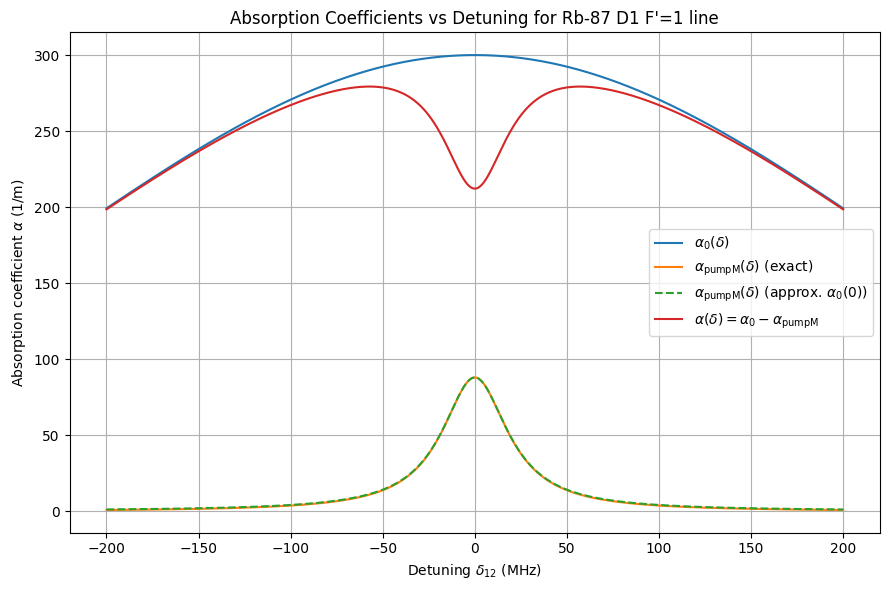

K_mSAS = 0.292893
Γ_mSAS = 43.612 MHz
α₀(0) = 3.000e+02 1/m


In [5]:
# in this visualization, the use of alpha_0(delta) and the delta->0 (alpha_0(0)) approximation is compared

# Detuning range (MHz → Hz)
delta_MHz = np.linspace(-200, 200, 801)
delta_Hz = delta_MHz * 1e6

# Compute α₀(δ)
alpha0_vals = compute_alpha0_numeric(delta_Hz, N, sigma_D11_0, u, lambda_D11, Gamma_D1)

# α₀(0) for approximation
alpha0_0 = np.interp(0.0, delta_Hz, alpha0_vals)

# Compute pump modification
alpha_pumpM_exact, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_Hz, I_pu, I_sat_D11, Gamma_D1)
alpha_pumpM_approx = alpha0_0 * K_mSAS * L(delta_Hz, Gamma_mSAS)

# Final α(δ)
alpha_total_exact = alpha0_vals - alpha_pumpM_exact
alpha_total_approx = alpha0_vals - alpha_pumpM_approx

# Plot
plt.figure(figsize=(9,6))
plt.plot(delta_MHz, alpha0_vals, label=r'$\alpha_0(\delta)$')
plt.plot(delta_MHz, alpha_pumpM_exact, label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (exact)')
plt.plot(delta_MHz, alpha_pumpM_approx, '--', label=r'$\alpha_{\mathrm{pumpM}}(\delta)$ (approx. $\alpha_0(0)$)')
plt.plot(delta_MHz, alpha_total_exact, label=r'$\alpha(\delta) = \alpha_0 - \alpha_{\mathrm{pumpM}}$')
plt.xlabel(r'Detuning $\delta_{12}$ (MHz)')
plt.ylabel(r'Absorption coefficient $\alpha$ (1/m)')
plt.title("Absorption Coefficients vs Detuning for Rb-87 D1 F'=1 line")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"K_mSAS = {K_mSAS:.6f}")
print(f"Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")
print(f"α₀(0) = {alpha0_0:.3e} 1/m")


### D1 to F'=1 and F'=2

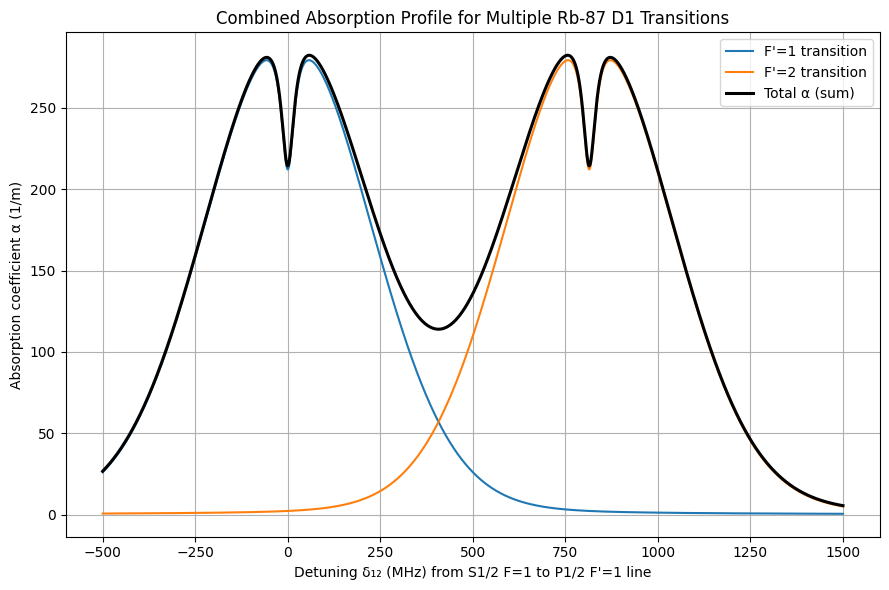

In [6]:
# Detuning range
delta_MHz = np.linspace(-500, 1500, 6401)
delta_Hz = delta_MHz * 1e6

# Define multiple transitions 
# "strength" is added in case the addition needs to be weighted
transitions = [
    {"strength":1.0, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":1.0, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]

# Compute α for each transition and sum
alpha_total = np.zeros_like(delta_Hz)
plt.figure(figsize=(9,6))

zero_f = transitions[0]["f0"]
for tr in transitions:
    delta_shifted_Hz = delta_Hz - (tr["f0"] - zero_f)
    alpha0_vals = compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"])
    alpha_pumpM, K_mSAS, Gamma_mSAS = compute_pumpM(alpha0_vals, delta_shifted_Hz, I_pu, tr["I_sat"], tr["Gamma"])
    alpha_vals = tr["strength"] * (alpha0_vals - alpha_pumpM)
    alpha_total += alpha_vals

    plt.plot(delta_MHz, alpha_vals, label=fr"{tr['label']} transition")

# Plot summed absorption
plt.plot(delta_MHz, alpha_total, 'k', linewidth=2.2, label="Total α (sum)")

plt.xlabel(r"Detuning δ₁₂ (MHz) from S1/2 F=1 to P1/2 F'=1 line")
plt.ylabel(r'Absorption coefficient α (1/m)')
plt.title('Combined Absorption Profile for Multiple Rb-87 D1 Transitions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
